In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
dataset_path = r"C:\Users\Acer\Documents\data\facemask\data"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 10
class_names = ["with_mask", "without_mask"]
print("Dataset path:", dataset_path)
print("Classes:", class_names)
print("\nPath exists:", os.path.exists(dataset_path))

Dataset path: C:\Users\Acer\Documents\data\facemask\data
Classes: ['with_mask', 'without_mask']

Path exists: True


In [3]:
for class_name in class_names:
    folder = os.path.join(dataset_path, class_name)
    
    files = os.listdir(folder)
    
    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    
    print(class_name, ":", len(image_files), "images")

with_mask : 3716 images
without_mask : 3828 images


In [4]:
train_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 7544 files belonging to 2 classes.
Using 6036 files for training.


In [5]:
val_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 7544 files belonging to 2 classes.
Using 1508 files for validation.


In [6]:
print("Class names:")
print(train_data.class_names)

Class names:
['with_mask', 'without_mask']


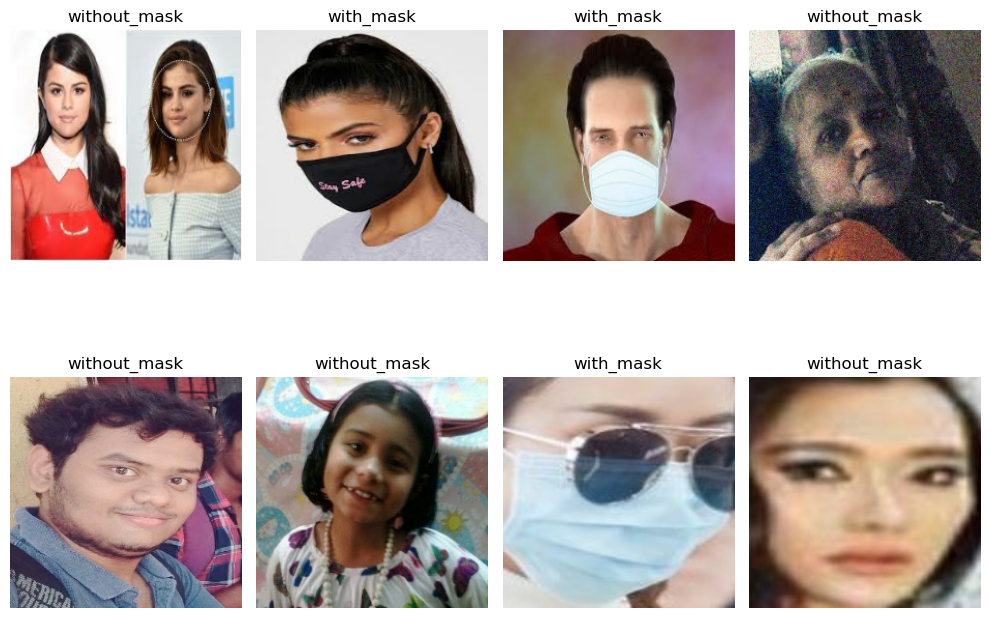

In [7]:
plt.figure(figsize=(10, 8))

for images, labels in train_data.take(1):
    
    for i in range(8):
        
        plt.subplot(2, 4, i + 1)
        
        plt.imshow(images[i].numpy().astype("uint8"))
        
        label = int(labels[i].numpy()[0])
        
        plt.title(class_names[label])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.prefetch(
    buffer_size=AUTOTUNE
)

val_data = val_data.prefetch(
    buffer_size=AUTOTUNE
)

In [11]:
train_data = train_data.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
)

val_data = val_data.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
)
data_augmentation = tf.keras.Sequential([
    
    layers.RandomFlip("horizontal"),
    
    layers.RandomRotation(0.1),
    
    layers.RandomZoom(0.1)
])

In [12]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

print("MobileNetV2 loaded successfully!")

MobileNetV2 loaded successfully!


In [13]:
base_model.trainable = False

print("Base model frozen.")

Base model frozen.


In [14]:
model = models.Sequential([
    
    layers.Input(shape=(224, 224, 3)),
    
    data_augmentation,
    
    base_model,
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(128, activation="relu"),
    
    layers.Dropout(0.5),
    
    layers.Dense(1, activation="sigmoid")
])

In [15]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    
    loss="binary_crossentropy",
    
    metrics=["accuracy"]
)

In [18]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 272s 631ms/step - accuracy: 0.9872 - loss: 0.0346 - val_accuracy: 0.9954 - val_loss: 0.0158
Epoch 2/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 268s 707ms/step - accuracy: 0.9914 - loss: 0.0249 - val_accuracy: 0.9960 - val_loss: 0.0207
Epoch 3/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 241s 637ms/step - accuracy: 0.9887 - loss: 0.0316 - val_accuracy: 0.9920 - val_loss: 0.0247
Epoch 4/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 263s 692ms/step - accuracy: 0.9901 - loss: 0.0307 - val_accuracy: 0.9940 - val_loss: 0.0196
Epoch 5/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 293s 617ms/step - accuracy: 0.9891 - loss: 0.0292 - val_accuracy: 0.9954 - val_loss: 0.0197


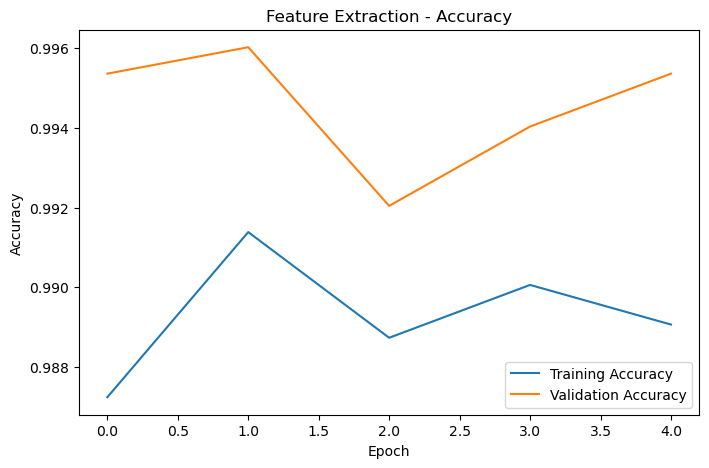

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Feature Extraction - Accuracy")

plt.legend()

plt.show()

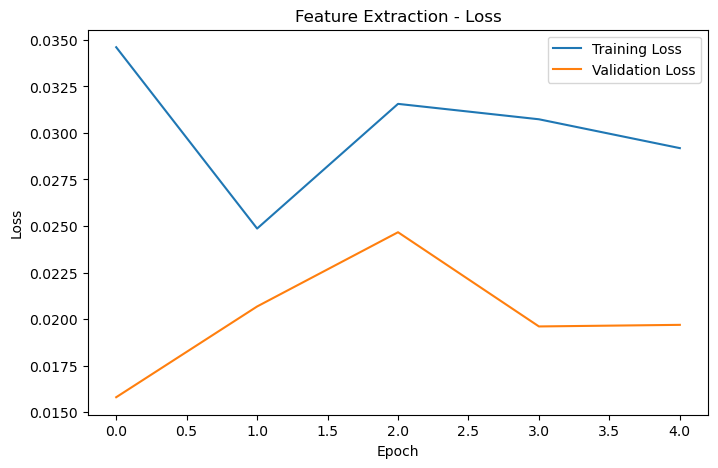

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Feature Extraction - Loss")

plt.legend()

plt.show()

In [21]:
loss, accuracy = model.evaluate(
    val_data,
    verbose=1
)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 392ms/step - accuracy: 0.9954 - loss: 0.0197
Validation Loss: 0.019689179956912994
Validation Accuracy: 0.9953581094741821


In [22]:
loss, accuracy = model.evaluate(
    val_data,
    verbose=1
)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

95/95 ━━━━━━━━━━━━━━━━━━━━ 37s 392ms/step - accuracy: 0.9954 - loss: 0.0197
Validation Loss: 0.019689185544848442
Validation Accuracy: 0.9953581094741821


In [23]:
base_model.trainable = True
print("Total layers:", len(base_model.layers))

Total layers: 154


In [24]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [25]:
for i, layer in enumerate(base_model.layers):
    
    print(
        i,
        layer.name,
        "Trainable =", layer.trainable
    )

0 input_layer Trainable = False
1 Conv1 Trainable = False
2 bn_Conv1 Trainable = False
3 Conv1_relu Trainable = False
4 expanded_conv_depthwise Trainable = False
5 expanded_conv_depthwise_BN Trainable = False
6 expanded_conv_depthwise_relu Trainable = False
7 expanded_conv_project Trainable = False
8 expanded_conv_project_BN Trainable = False
9 block_1_expand Trainable = False
10 block_1_expand_BN Trainable = False
11 block_1_expand_relu Trainable = False
12 block_1_pad Trainable = False
13 block_1_depthwise Trainable = False
14 block_1_depthwise_BN Trainable = False
15 block_1_depthwise_relu Trainable = False
16 block_1_project Trainable = False
17 block_1_project_BN Trainable = False
18 block_2_expand Trainable = False
19 block_2_expand_BN Trainable = False
20 block_2_expand_relu Trainable = False
21 block_2_depthwise Trainable = False
22 block_2_depthwise_BN Trainable = False
23 block_2_depthwise_relu Trainable = False
24 block_2_project Trainable = False
25 block_2_project_BN Train

In [26]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.00001
    ),
    
    loss="binary_crossentropy",
    
    metrics=["accuracy"]
)

In [27]:
FINE_TUNE_EPOCHS = 5

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=FINE_TUNE_EPOCHS
)

Epoch 1/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 333s 737ms/step - accuracy: 0.9511 - loss: 0.1464 - val_accuracy: 0.9920 - val_loss: 0.0254
Epoch 2/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 281s 742ms/step - accuracy: 0.9684 - loss: 0.0790 - val_accuracy: 0.9947 - val_loss: 0.0195
Epoch 3/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 288s 762ms/step - accuracy: 0.9788 - loss: 0.0615 - val_accuracy: 0.9940 - val_loss: 0.0200
Epoch 4/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 308s 815ms/step - accuracy: 0.9786 - loss: 0.0611 - val_accuracy: 0.9954 - val_loss: 0.0190
Epoch 5/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 292s 770ms/step - accuracy: 0.9851 - loss: 0.0421 - val_accuracy: 0.9960 - val_loss: 0.0189


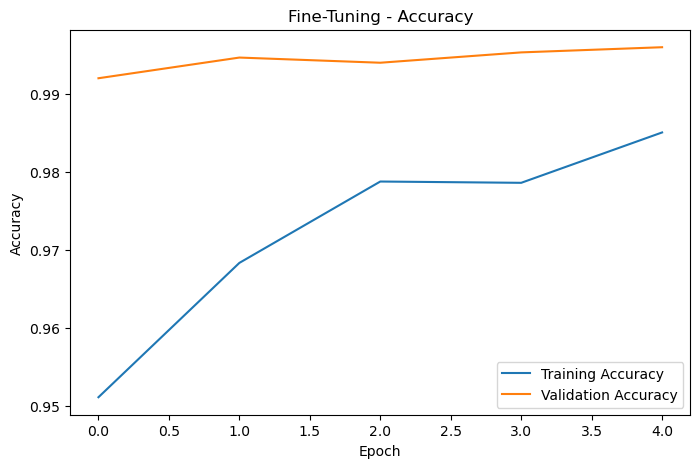

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_fine.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_fine.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Fine-Tuning - Accuracy")

plt.legend()

plt.show()

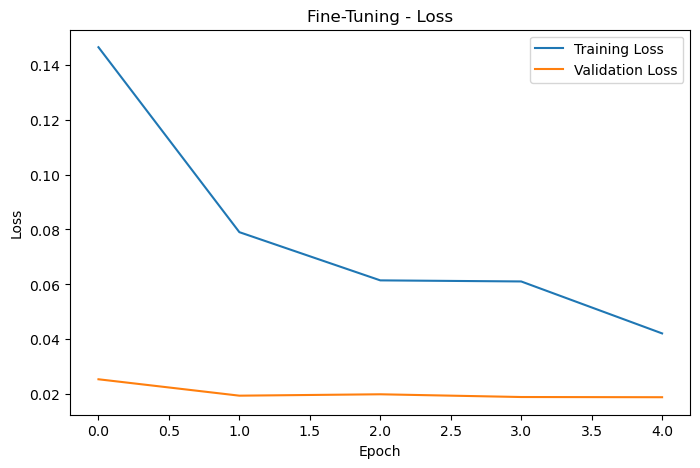

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_fine.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_fine.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Fine-Tuning - Loss")

plt.legend()

plt.show()

In [30]:
final_loss, final_accuracy = model.evaluate(
    val_data,
    verbose=1
)

print("Final Loss:", final_loss)
print("Final Accuracy:", final_accuracy)

95/95 ━━━━━━━━━━━━━━━━━━━━ 49s 515ms/step - accuracy: 0.9960 - loss: 0.0189
Final Loss: 0.01890377886593342
Final Accuracy: 0.9960212111473083


In [31]:
y_true = []
y_pred = []

for images, labels in val_data:
    
    predictions = model.predict(
        images,
        verbose=0
    )
    
    predictions = (predictions > 0.5).astype(int).flatten()
    
    y_pred.extend(predictions)
    y_true.extend(labels.numpy().astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   with_mask       0.99      1.00      1.00       739
without_mask       1.00      0.99      1.00       769

    accuracy                           1.00      1508
   macro avg       1.00      1.00      1.00      1508
weighted avg       1.00      1.00      1.00      1508



In [32]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[738   1]
 [  5 764]]


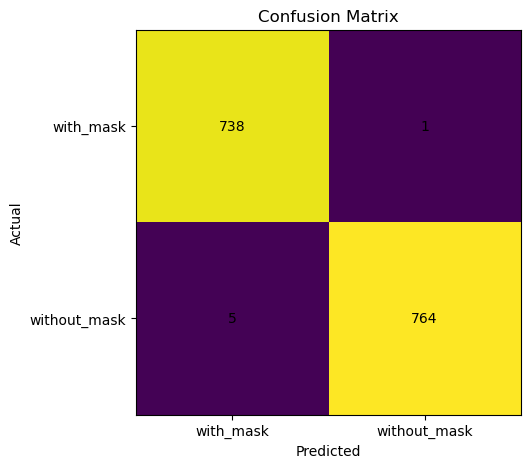

In [33]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xticks(
    [0, 1],
    class_names
)

plt.yticks(
    [0, 1],
    class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [34]:
model.save("face_mask.h5")
print("Model saved successfully!")

Model saved successfully!
